In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Original Text Snippet:
 ﻿The Project Gutenberg eBook of The Prophet
    
This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this ebook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title:  ...

Number of Sentences: 744

First 20 Tokens: ['\ufeffThe', 'Project', 'Gutenberg', 'eBook', 'of', 'The', 'Prophet', 'This', 'ebook', 'is', 'for', 'the', 'use', 'of', 'anyone', 'anywhere', 'in', 'the', 'United', 'States'] 

First 20 Cleaned Tokens (punctuation removed): ['Project', 'Gutenberg', 'eBook', 'of', 'The', 'Prophet', 'This', 'ebook', 'is', 'for', 'the', 'use', 'of', 'anyone', 'anywhere', 'in', 'the', 'United', 'States', 'and'] 

First 20 Stemmed Words: ['proj

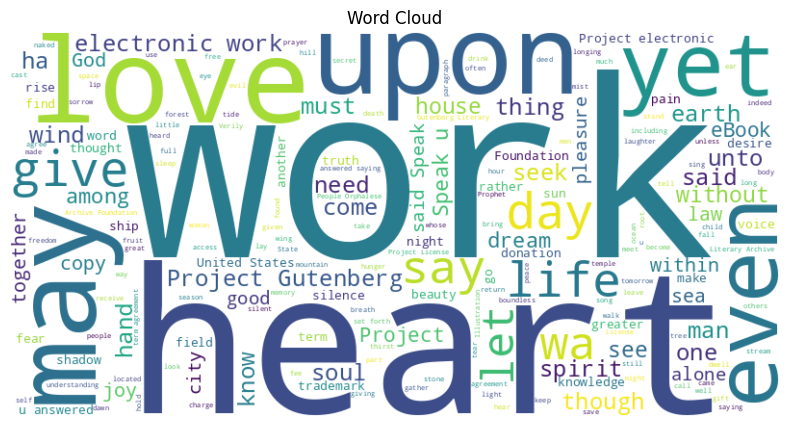

In [22]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from nltk import pos_tag, FreqDist, Text
from nltk.probability import FreqDist
import string
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Download necessary NLTK resources
nltk.download('punkt')  # For tokenization
nltk.download('stopwords')  # For stop words
nltk.download('averaged_perceptron_tagger')  # For POS tagging
nltk.download('wordnet')  # For lemmatization
nltk.download('punkt_tab') # Explicitly download punkt_tab as suggested by the error
nltk.download('averaged_perceptron_tagger_eng') # Explicitly download for English POS tagging

# Function to read the text file
def read_text_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        text = file.read()
    return text

# Function to count paragraphs (assuming paragraphs are separated by blank lines)
def count_paragraphs(text):
    paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()]
    return len(paragraphs), paragraphs

# Function to count sentences
def count_sentences(text):
    sentences = sent_tokenize(text)
    return len(sentences), sentences

# Function for data cleaning: remove punctuation and non-alphabetic words
def clean_text(tokens):
    cleaned = [re.sub(r'[^Ȁ-ɿ\w\s]', '', word) for word in tokens if word.isalpha()]  # Remove punctuation and keep only alphabetic words
    return [word for word in cleaned if word]  # Remove empty strings

# Main processing function
def process_nlp(file_path):
    # Read the file
    text = read_text_file(file_path)
    print("Original Text Snippet:\n", text[:500], "...\n")  # Print first 500 chars

    # Count paragraphs
    #num_paragraphs, paragraphs = count_paragraphs(text)
    #print(f"Number of Paragraphs: {num_paragraphs}\n")

    # Count sentences
    num_sentences, sentences = count_sentences(text)
    print(f"Number of Sentences: {num_sentences}\n")

    # Tokenization (word level)
    tokens = word_tokenize(text)
    print("First 20 Tokens:", tokens[:20], "\n")

    # Data cleaning: remove punctuation and non-alphabetic words
    cleaned_tokens = clean_text(tokens)
    print("First 20 Cleaned Tokens (punctuation removed):", cleaned_tokens[:20], "\n")

    # Stemming
    stemmer = PorterStemmer()
    stemmed = [stemmer.stem(word) for word in cleaned_tokens]
    print("First 20 Stemmed Words:", stemmed[:20], "\n")

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    lemmatized = [lemmatizer.lemmatize(word) for word in cleaned_tokens]
    print("First 20 Lemmatized Words:", lemmatized[:20], "\n")

    # Stop word removal
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in lemmatized if word.lower() not in stop_words]
    print("First 20 Tokens after Stop Word Removal:", filtered_tokens[:20], "\n")

    # POS Tagging (on filtered tokens)
    pos_tags = pos_tag(filtered_tokens)
    print("First 20 POS Tags:", pos_tags[:20], "\n")

    # Concordance
    nltk_text = Text(filtered_tokens)
    print("Concordance for 'love':")
    nltk_text.concordance('love', lines=5)  # Change 'example' to any word
    print("\n")

    # Frequency of words
    freq_dist = FreqDist(filtered_tokens)
    print("Top 10 Most Common Words:", freq_dist.most_common(10), "\n")

    # Build and save Word Cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(filtered_tokens))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud')
    plt.savefig('wordcloud.png')
    print("Word Cloud saved as 'wordcloud.png'\n")

# Run the script
if __name__ == "__main__":
    file_path = '/content/drive/MyDrive/pg58585.txt'  # Replace with your file path
    process_nlp(file_path)

In [15]:
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

examples = [
    "I am thrilled about the new job, but a bit nervous about the first day.",
    "The concert was terrible and the crowd was hostile.",
    "She smiled with joy when she received the good news.",
    "I'm so disappointed and angry about the service."
]

analyzer = SentimentIntensityAnalyzer()

def classify(compound, pos_thresh=0.05, neg_thresh=-0.05):
    if compound >= pos_thresh:
        return "positive"
    if compound <= neg_thresh:
        return "negative"
    return "neutral"

for i, text in enumerate(examples, 1):
    scores = analyzer.polarity_scores(text)
    sentiment = classify(scores["compound"])
    print(f"\nSentence {i}: {text}")
    print("Scores:", scores)
    print("Overall sentiment:", sentiment)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.9 MB/s eta 0:00:00

Sentence 1: I am thrilled about the new job, but a bit nervous about the first day.
Scores: {'neg': 0.151, 'neu': 0.739, 'pos': 0.111, 'compound': -0.1779}
Overall sentiment: negative

Sentence 2: The concert was terrible and the crowd was hostile.
Scores: {'neg': 0.449, 'neu': 0.551, 'pos': 0.0, 'compound': -0.6908}
Overall sentiment: negative

Sentence 3: She smiled with joy when she received the good news.
Scores: {'neg': 0.0, 'neu': 0.407, 'pos': 0.593, 'compound': 0.8807}
Overall sentiment: positive

Sentence 4: I'm so disappointed and angry about the service.
Scores: {'neg': 0.537, 'neu': 0.463, 'pos': 0.0, 'compound': -0.788}
Overall sentiment: negative


Cluster assignments:
[Cluster 2] I love hiking in the mountains and exploring nature trails.
[Cluster 0] The new smartphone has an amazing camera and battery life.
[Cluster 2] Baking bread at home is therapeutic and yields delicious results.
[Cluster 1] Our team won the soccer match after a thrilling comeback.
[Cluster 0] I updated my phone's software and the camera quality improved.
[Cluster 2] Trail running and mountain biking are my favorite outdoor activities.
[Cluster 2] She made sourdough for the first time and it turned out great.
[Cluster 1] He scored the winning goal in the last minute of the game.
[Cluster 0] Photography and videography are popular on the new phone models.
[Cluster 2] We went camping last weekend and hiked several rugged trails.
[Cluster 2] The bakery sells fresh croissants and artisan sourdough daily.
[Cluster 1] The championship match had an incredible final goal.

Top terms per cluster:
Cluster 0: phone, new, camera, updated, quality, smartphone
Cluster 1:

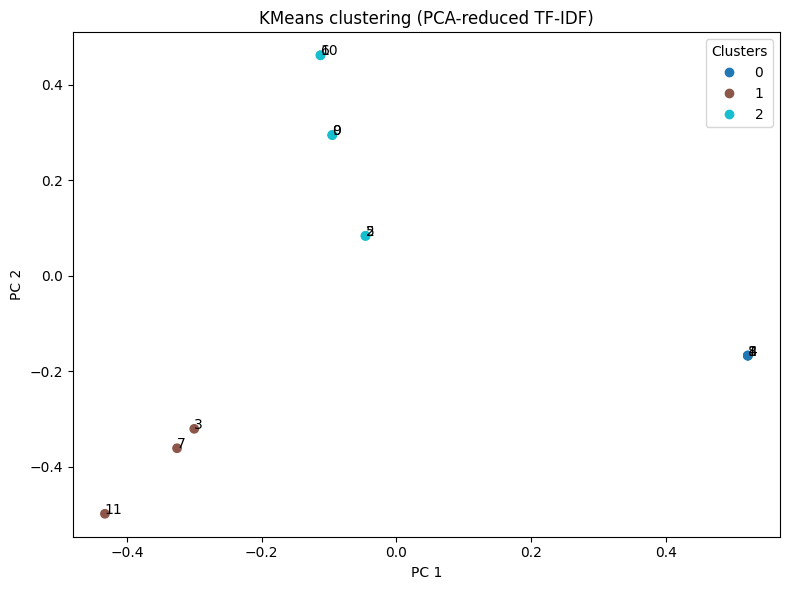

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np

# Example sentences to cluster
documents = [
    "I love hiking in the mountains and exploring nature trails.",
    "The new smartphone has an amazing camera and battery life.",
    "Baking bread at home is therapeutic and yields delicious results.",
    "Our team won the soccer match after a thrilling comeback.",
    "I updated my phone's software and the camera quality improved.",
    "Trail running and mountain biking are my favorite outdoor activities.",
    "She made sourdough for the first time and it turned out great.",
    "He scored the winning goal in the last minute of the game.",
    "Photography and videography are popular on the new phone models.",
    "We went camping last weekend and hiked several rugged trails.",
    "The bakery sells fresh croissants and artisan sourdough daily.",
    "The championship match had an incredible final goal.",
]

# Number of clusters
num_clusters = 3
random_state = 42

# 1) Vectorize with TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.8, min_df=1)
X = vectorizer.fit_transform(documents)

# 2) KMeans clustering
km = KMeans(n_clusters=num_clusters, random_state=random_state, n_init=10)
km.fit(X)
labels = km.labels_

# 3) Print cluster assignments
print("Cluster assignments:")
for i, doc in enumerate(documents):
    print(f"[Cluster {labels[i]}] {doc}")

# 4) Show top terms per cluster
def top_terms_per_cluster(km_model, vectorizer, n_terms=6):
    order_centroids = km_model.cluster_centers_.argsort()[:, ::-1]
    terms = vectorizer.get_feature_names_out()
    clusters = {}
    for i in range(km_model.n_clusters):
        top_terms = [terms[ind] for ind in order_centroids[i, :n_terms]]
        clusters[i] = top_terms
    return clusters

print("\nTop terms per cluster:")
clusters_terms = top_terms_per_cluster(km, vectorizer, n_terms=6)
for c, terms in clusters_terms.items():
    print(f"Cluster {c}: {', '.join(terms)}")

# 5) (Optional) 2D visualization using PCA
try:
    import matplotlib.pyplot as plt
    pca = PCA(n_components=2, random_state=random_state)
    X_reduced = pca.fit_transform(X.toarray())
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_reduced[:,0], X_reduced[:,1], c=labels, cmap='tab10')
    for i, txt in enumerate(range(len(documents))):
        plt.annotate(str(i), (X_reduced[i,0], X_reduced[i,1]))
    plt.title("KMeans clustering (PCA-reduced TF-IDF)")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend(*scatter.legend_elements(), title="Clusters")
    plt.tight_layout()
    plt.show()
except Exception:
    pass


In [19]:
!pip install gensim
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim import corpora
from gensim.models import LdaModel

# Download NLTK resources (run once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab') # Added to address the LookupError

documents = [
    "I love hiking in the mountains and exploring nature trails.",
    "The new smartphone has an amazing camera and battery life.",
    "Baking bread at home is therapeutic and yields delicious results.",
    "Our team won the soccer match after a thrilling comeback.",
    "I updated my phone's software and the camera quality improved.",
    "Trail running and mountain biking are my favorite outdoor activities.",
    "She made sourdough for the first time and it turned out great.",
    "He scored the winning goal in the last minute of the game.",
    "Photography and videography are popular on the new phone models.",
    "We went camping last weekend and hiked several rugged trails.",
    "The bakery sells fresh croissants and artisan sourdough daily.",
    "The championship match had an incredible final goal.",
]

# Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = nltk.word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

texts = [preprocess(doc) for doc in documents]

# Create dictionary and corpus
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# LDA parameters
num_topics = 3
passes = 20
random_state = 42

# Train LDA model
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics,
               passes=passes, random_state=random_state)

# Print topics
print("Topics (word:weight):")
for i, topic in lda.print_topics(num_topics=num_topics, num_words=6):
    print(f"Topic {i}: {topic}")

# Topic distribution per document
print("\nDocument topic distributions:")
for idx, bow in enumerate(corpus):
    dist = lda.get_document_topics(bow)
    dist_sorted = sorted(dist, key=lambda x: -x[1])
    print(f"Doc {idx} (top topic {dist_sorted[0][0]}): {dist_sorted}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Topics (word:weight):
Topic 0: 0.060*"trail" + 0.042*"last" + 0.042*"mountain" + 0.024*"goal" + 0.024*"rugged" + 0.024*"went"
Topic 1: 0.046*"camera" + 0.046*"phone" + 0.046*"new" + 0.026*"goal" + 0.026*"updated" + 0.026*"life"
Topic 2: 0.040*"match" + 0.040*"sourdough" + 0.040*"sell" + 0.040*"croissant" + 0.040*"artisan" + 0.040*"bakery"

Document topic distributions:
Doc 0 (top topic 0): [(0, np.float32(0.9040346)), (2, np.float32(0.048059173)), (1, np.float32(0.047906216))]
Doc 1 (top topic 1): [(1, np.float32(0.9041044)), (2, np.float32(0.048032023)), (0, np.float32(0.047863577))]
Doc 2 (top topic 0): [(0, np.float32(0.9158678)), (2, np.float32(0.042150192)), (1, np.float32(0.04198201))]
Doc 3 (top topic 2): [(2, np.float32(0.8873956)), (1, np.float32(0.056819763)), (0, np.float32(0.055784598))]
Doc 4 (top topic 1): [(1, np.float32(0.904104)), (2, np.float32(0.04803237)), (0, np.float32(0.047863696))]
Doc 5 (top topic 0): [(0, np.float32(0.91600686)), (2, np.float32(0.04206671)), (